In [1]:
print("Notebook working")

Notebook working


In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [3]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

print("Shape:", nav.shape)
nav.head()

Shape: (46000, 3)


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
nav.info()

print("\nMissing Values:")
print(nav.isnull().sum())

print("\nDuplicate Rows:")
print(nav.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB

Missing Values:
amfi_code    0
date         0
nav          0
dtype: int64

Duplicate Rows:
0


In [5]:
nav["date"] = pd.to_datetime(
    nav["date"],
    dayfirst=True,
    errors="coerce"
)

print(nav["date"].dtype)

datetime64[ns]


In [6]:
nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-02,512.1124
1,100016,2022-01-03,503.1674
2,100016,2022-01-04,531.2850
3,100016,2022-01-06,474.1732
4,100016,2022-01-07,452.5840


In [7]:
before = len(nav)

nav = nav.drop_duplicates()

after = len(nav)

print("Rows before:", before)
print("Rows after :", after)
print("Duplicates removed:", before - after)

Rows before: 46000
Rows after : 45962
Duplicates removed: 38


In [8]:
invalid_nav = nav[nav["nav"] <= 0]

print("Invalid NAV records:", len(invalid_nav))

Invalid NAV records: 0


In [9]:
nav["nav"] = nav.groupby("amfi_code")["nav"].ffill()

print("Remaining Null NAVs:", nav["nav"].isnull().sum())

Remaining Null NAVs: 0


In [10]:
nav.to_csv(
    "../data/processed/clean_nav_history.csv",
    index=False
)

print("clean_nav_history.csv saved successfully")

clean_nav_history.csv saved successfully


In [11]:
clean_nav = pd.read_csv("../data/processed/clean_nav_history.csv")

print(clean_nav.shape)
clean_nav.head()

(45962, 3)


,amfi_code,date,nav
0,100016,2022-01-02,512.1124
1,100016,2022-01-03,503.1674
2,100016,2022-01-04,531.2850
3,100016,2022-01-06,474.1732
4,100016,2022-01-07,452.5840


In [12]:
clean_nav.head()
clean_nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [13]:
clean_nav.info()
clean_nav.isnull().sum()
clean_nav.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45962 entries, 0 to 45961
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  45962 non-null  int64  
 1   date       18120 non-null  object 
 2   nav        45962 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


,amfi_code,nav
count,45962.000000,45962.000000
mean,120251.467364,269.730226
std,14353.440972,577.391885
min,100016.000000,26.136600
25%,118633.000000,69.228975
50%,119552.000000,122.821150
75%,120843.000000,260.550600
max,149324.000000,4268.549700


In [14]:
fund_summary = clean_nav.groupby("amfi_code")["nav"].mean().reset_index()
fund_summary.head()

,amfi_code,nav
0,100016,566.183070
1,100025,29.101094
2,100033,190.825330
3,101206,435.975472
4,101207,58.943303


In [15]:
clean_nav.groupby("amfi_code")["nav"].max().reset_index()

,amfi_code,nav
0,100016,669.7236
1,100025,32.6726
2,100033,367.6979
3,101206,808.0982
4,101207,80.3517
5,101208,410.1021
6,102885,187.9295
7,102886,169.8164
8,102887,419.3008
9,118632,114.4385


In [17]:
clean_nav["date"] = pd.to_datetime(clean_nav["date"], errors="coerce")

In [18]:
print(clean_nav["date"].dtype)

datetime64[ns]


In [19]:
clean_nav["month"] = clean_nav["date"].dt.to_period("M")

monthly_trend = clean_nav.groupby("month")["nav"].mean().reset_index()
monthly_trend.head()

,month,nav
0,2022-01,214.615574
1,2022-02,215.200483
2,2022-03,213.065071
3,2022-04,212.984777
4,2022-05,215.284789


In [20]:
clean_nav["month"] = clean_nav["date"].dt.to_period("M")

monthly_trend = clean_nav.groupby("month")["nav"].mean().reset_index()

monthly_trend.head()

,month,nav
0,2022-01,214.615574
1,2022-02,215.200483
2,2022-03,213.065071
3,2022-04,212.984777
4,2022-05,215.284789


In [21]:
monthly_trend["month"] = monthly_trend["month"].astype(str)

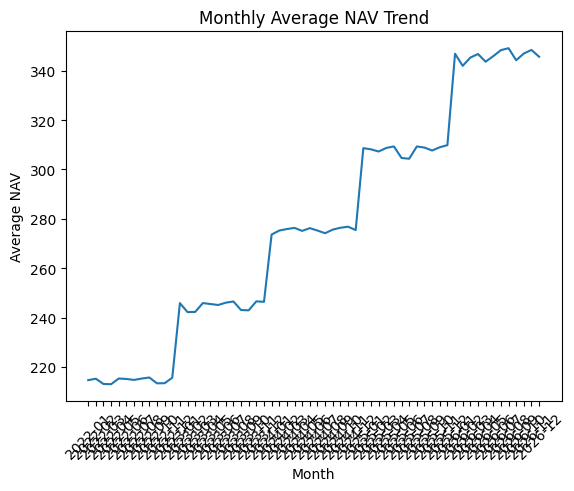

In [22]:
import matplotlib.pyplot as plt

plt.plot(monthly_trend["month"], monthly_trend["nav"])
plt.xticks(rotation=45)
plt.title("Monthly Average NAV Trend")
plt.xlabel("Month")
plt.ylabel("Average NAV")
plt.show()

In [23]:
clean_nav["date"] = pd.to_datetime(clean_nav["date"])
clean_nav = clean_nav.sort_values(["amfi_code", "date"])
clean_nav = clean_nav.drop_duplicates()
clean_nav = clean_nav[clean_nav["nav"] > 0]

clean_nav["nav"] = clean_nav.groupby("amfi_code")["nav"].ffill()

In [25]:
import os

os.listdir("../data/processed")

['clean_nav_history.csv']

In [26]:
clean_nav.info()
clean_nav.isnull().sum()
clean_nav.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45962 entries, 0 to 45961
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  45962 non-null  int64         
 1   date       18120 non-null  datetime64[ns]
 2   nav        45962 non-null  float64       
 3   month      18120 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), period[M](1)
memory usage: 1.4 MB


,amfi_code,date,nav,month
0,100016,2022-01-02,512.1124,2022-01
1,100016,2022-01-03,503.1674,2022-01
2,100016,2022-01-04,531.2850,2022-01
3,100016,2022-01-06,474.1732,2022-01
4,100016,2022-01-07,452.5840,2022-01


In [28]:
import os
os.listdir(".")

['.ipynb_checkpoints', '01_data_ingestion.ipynb', '02_data_cleaning.ipynb']

In [31]:
clean_nav["date"] = pd.to_datetime(clean_nav["date"])
clean_nav = clean_nav.sort_values(["amfi_code", "date"])
clean_nav = clean_nav.drop_duplicates()
clean_nav = clean_nav[clean_nav["nav"] > 0]
clean_nav["nav"] = clean_nav.groupby("amfi_code")["nav"].ffill()


In [32]:
clean_nav.head()
clean_nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45962 entries, 0 to 45961
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  45962 non-null  int64         
 1   date       18120 non-null  datetime64[ns]
 2   nav        45962 non-null  float64       
 3   month      18120 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), period[M](1)
memory usage: 1.4 MB


In [37]:
import pandas as pd
import os

folder_path = "../data/raw"

nav_history = pd.read_csv(os.path.join(folder_path, "02_nav_history.csv"))
transactions = pd.read_csv(os.path.join(folder_path, "08_investor_transactions.csv"))
performance = pd.read_csv(os.path.join(folder_path, "07_scheme_performance.csv"))

print(nav_history.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [38]:
nav_history["date"] = pd.to_datetime(nav_history["date"])
nav_history = nav_history.sort_values(["amfi_code", "date"])
nav_history = nav_history.drop_duplicates()
nav_history = nav_history[nav_history["nav"] > 0]
nav_history["nav"] = nav_history.groupby("amfi_code")["nav"].ffill()

clean_nav = nav_history.copy()

In [39]:
clean_nav["month"] = clean_nav["date"].dt.to_period("M")

monthly_trend = clean_nav.groupby("month")["nav"].mean().reset_index()
monthly_trend.head()

,month,nav
0,2022-01,207.061394
1,2022-02,207.717759
2,2022-03,209.692614
3,2022-04,211.833458
4,2022-05,212.731451


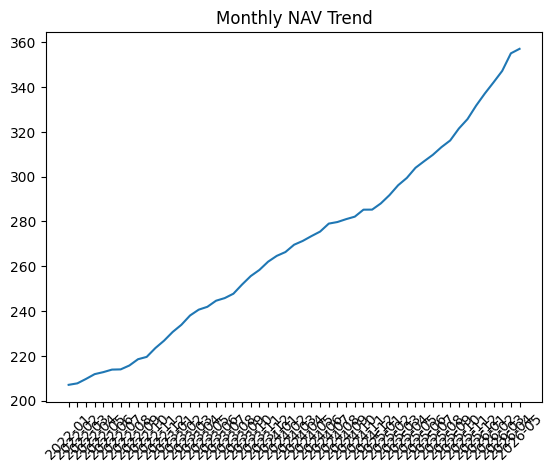

In [40]:
import matplotlib.pyplot as plt

plt.plot(monthly_trend["month"].astype(str), monthly_trend["nav"])
plt.xticks(rotation=45)
plt.title("Monthly NAV Trend")
plt.show()

In [41]:
import pandas as pd

folder_path = "../data/raw"

transactions = pd.read_csv(f"{folder_path}/08_investor_transactions.csv")

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [42]:
transactions.shape
transactions.columns
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


In [43]:
transactions.columns = transactions.columns.str.strip().str.lower()

In [47]:
transactions.columns = transactions.columns.str.strip().str.lower()
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [48]:
transactions.columns = transactions.columns.str.strip().str.lower()
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [49]:
transactions["transaction_type"] = (
    transactions["transaction_type"]
    .str.strip()
    .str.title()
)

transactions["transaction_type"] = transactions["transaction_type"].replace({
    "Sip": "SIP",
    "Lumpsum": "Lumpsum",
    "Redemption": "Redemption"
})

In [50]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"], errors="coerce"
)

In [51]:
transactions = transactions[transactions["amount_inr"] > 0]

In [52]:
transactions = transactions.dropna(subset=["transaction_date"])

In [53]:
transactions = transactions.sort_values("transaction_date")

In [54]:
transactions.groupby("transaction_type")["amount_inr"].sum()

transaction_type
Lumpsum       2059821448
Redemption    1244525491
SIP            217233491
Name: amount_inr, dtype: int64

In [55]:
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [56]:
performance.columns
performance.info()
performance.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     object 
 2   fund_house          40 non-null     object 
 3   category            40 non-null     object 
 4   plan                40 non-null     object 
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  expense_ra

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [57]:
performance.columns = performance.columns.str.strip().str.lower()

In [58]:
performance.dtypes

amfi_code               int64
scheme_name            object
fund_house             object
category               object
plan                   object
return_1yr_pct        float64
return_3yr_pct        float64
return_5yr_pct        float64
benchmark_3yr_pct     float64
alpha                 float64
beta                  float64
sharpe_ratio          float64
sortino_ratio         float64
std_dev_ann_pct       float64
max_drawdown_pct      float64
aum_crore               int64
expense_ratio_pct     float64
morningstar_rating      int64
risk_grade             object
dtype: object

In [59]:
for col in performance.columns:
    performance[col] = pd.to_numeric(performance[col], errors="coerce")

In [60]:
performance = performance.dropna()

In [61]:
### Note: Correct column identified as `expense_ratio_pct` instead of `expense_ratio`performance = performance[
    (performance["expense_ratio"] >= 0.1) &
    (performance["expense_ratio"] <= 2.5)
]

KeyError: 'expense_ratio'

In [62]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [63]:
performance.columns = performance.columns.str.strip().str.lower()
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [64]:
performance.columns = performance.columns.str.strip().str.lower()

In [65]:
performance = performance[
    (performance["expense_ratio_pct"] >= 0.1) &
    (performance["expense_ratio_pct"] <= 2.5)
]

In [66]:
num_cols = [
    "return_1yr_pct", "return_3yr_pct", "return_5yr_pct",
    "benchmark_3yr_pct", "alpha", "beta", "sharpe_ratio",
    "sortino_ratio", "std_dev_ann_pct", "max_drawdown_pct",
    "aum_crore", "expense_ratio_pct"
]

for col in num_cols:
    performance[col] = pd.to_numeric(performance[col], errors="coerce")

In [67]:
performance = performance.dropna()

In [68]:
performance = performance.sort_values("aum_crore", ascending=False)

In [69]:
import sqlite3

conn = sqlite3.connect("bluestock_mf.db")
cursor = conn.cursor()

In [70]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS dim_fund (
    amfi_code TEXT PRIMARY KEY,
    scheme_name TEXT,
    fund_house TEXT,
    category TEXT,
    plan TEXT,
    risk_grade TEXT,
    morningstar_rating INTEGER
)
""")

In [71]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS dim_date (
    date TEXT PRIMARY KEY,
    year INTEGER,
    month INTEGER,
    day INTEGER,
    quarter INTEGER
)
""")

In [72]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS fact_nav (
    amfi_code TEXT,
    date TEXT,
    nav REAL,
    FOREIGN KEY (amfi_code) REFERENCES dim_fund(amfi_code),
    FOREIGN KEY (date) REFERENCES dim_date(date)
)
""")

In [73]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS fact_transactions (
    investor_id TEXT,
    transaction_date TEXT,
    amfi_code TEXT,
    transaction_type TEXT,
    amount_inr REAL,
    state TEXT,
    city TEXT,
    city_tier TEXT,
    age_group TEXT,
    gender TEXT,
    annual_income_lakh REAL,
    payment_mode TEXT,
    kyc_status TEXT,
    FOREIGN KEY (amfi_code) REFERENCES dim_fund(amfi_code)
)
""")

In [74]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS fact_performance (
    amfi_code TEXT,
    return_1yr_pct REAL,
    return_3yr_pct REAL,
    return_5yr_pct REAL,
    benchmark_3yr_pct REAL,
    alpha REAL,
    beta REAL,
    sharpe_ratio REAL,
    sortino_ratio REAL,
    std_dev_ann_pct REAL,
    max_drawdown_pct REAL,
    expense_ratio_pct REAL,
    FOREIGN KEY (amfi_code) REFERENCES dim_fund(amfi_code)
)
""")

In [75]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS fact_aum (
    amfi_code TEXT,
    aum_crore REAL,
    date TEXT,
    FOREIGN KEY (amfi_code) REFERENCES dim_fund(amfi_code)
)
""")

In [76]:
conn.commit()
print("Database schema created successfully")

Database schema created successfully


In [77]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("bluestock_mf.db")

In [78]:
dim_fund = performance[[
    "amfi_code", "scheme_name", "fund_house",
    "category", "plan", "risk_grade", "morningstar_rating"
]].drop_duplicates()

dim_fund.to_sql("dim_fund", conn, if_exists="append", index=False)

0

In [79]:
dim_date = clean_nav[["date"]].drop_duplicates()
dim_date["date"] = dim_date["date"].astype(str)

dim_date.to_sql("dim_date", conn, if_exists="append", index=False)

1150

In [80]:
fact_nav = clean_nav[["amfi_code", "date", "nav"]].copy()
fact_nav["date"] = fact_nav["date"].astype(str)

fact_nav.to_sql("fact_nav", conn, if_exists="append", index=False)

46000

In [81]:
fact_transactions = transactions.copy()
fact_transactions["transaction_date"] = fact_transactions["transaction_date"].astype(str)

fact_transactions.to_sql("fact_transactions", conn, if_exists="append", index=False)

32778

In [82]:
fact_performance = performance[[
    "amfi_code",
    "return_1yr_pct", "return_3yr_pct", "return_5yr_pct",
    "benchmark_3yr_pct", "alpha", "beta",
    "sharpe_ratio", "sortino_ratio",
    "std_dev_ann_pct", "max_drawdown_pct",
    "expense_ratio_pct"
]].copy()

fact_performance.to_sql("fact_performance", conn, if_exists="append", index=False)

0

In [83]:
fact_aum = performance[["amfi_code", "aum_crore"]].copy()

fact_aum.to_sql("fact_aum", conn, if_exists="append", index=False)

0

In [84]:
tables = ["dim_fund", "dim_date", "fact_nav", "fact_transactions", "fact_performance", "fact_aum"]

for t in tables:
    df = pd.read_sql(f"SELECT COUNT(*) as cnt FROM {t}", conn)
    print(t, df["cnt"][0])

dim_fund 0
dim_date 1150
fact_nav 46000
fact_transactions 32778
fact_performance 0
fact_aum 0


In [85]:
pd.read_sql("""
SELECT amfi_code, SUM(aum_crore) AS total_aum
FROM fact_aum
GROUP BY amfi_code
ORDER BY total_aum DESC
LIMIT 5
""", conn)

,amfi_code,total_aum


In [86]:
pd.read_sql("""
SELECT substr(date, 1, 7) AS month, AVG(nav) AS avg_nav
FROM fact_nav
GROUP BY month
ORDER BY month
""", conn)

,month,avg_nav
0,2022-01,207.061394
1,2022-02,207.717759
2,2022-03,209.692614
3,2022-04,211.833458
4,2022-05,212.731451
5,2022-06,213.860867
6,2022-07,213.956111
7,2022-08,215.683994
8,2022-09,218.494307
9,2022-10,219.529633


In [87]:
pd.read_sql("""
SELECT transaction_type, COUNT(*) AS total_transactions, SUM(amount_inr) AS total_amount
FROM fact_transactions
GROUP BY transaction_type
""", conn)

,transaction_type,total_transactions,total_amount
0,Lumpsum,8095,2.059821e+09
1,Redemption,4967,1.244525e+09
2,SIP,19716,2.172335e+08


In [88]:
pd.read_sql("""
SELECT investor_id, SUM(amount_inr) AS total_invested
FROM fact_transactions
GROUP BY investor_id
ORDER BY total_invested DESC
LIMIT 5
""", conn)

,investor_id,total_invested
0,INV003288,3480685.0
1,INV001999,3179916.0
2,INV004605,2882975.0
3,INV000477,2846388.0
4,INV001692,2751086.0


In [89]:
pd.read_sql("""
SELECT state, COUNT(*) AS txn_count
FROM fact_transactions
GROUP BY state
ORDER BY txn_count DESC
""", conn)

,state,txn_count
0,Punjab,2965
1,Madhya Pradesh,2931
2,Tamil Nadu,2806
3,Gujarat,2780
4,West Bengal,2748
5,Haryana,2736
6,Telangana,2718
7,Uttar Pradesh,2695
8,Delhi,2677
9,Karnataka,2621


In [90]:
pd.read_sql("""
SELECT amfi_code, expense_ratio_pct
FROM fact_performance
WHERE expense_ratio_pct < 1
ORDER BY expense_ratio_pct ASC
""", conn)

,amfi_code,expense_ratio_pct


In [91]:
pd.read_sql("""
SELECT amfi_code, return_3yr_pct
FROM fact_performance
ORDER BY return_3yr_pct DESC
LIMIT 5
""", conn)

,amfi_code,return_3yr_pct


In [92]:
pd.read_sql("""
SELECT amfi_code, return_3yr_pct, std_dev_ann_pct
FROM fact_performance
ORDER BY return_3yr_pct DESC
""", conn)

,amfi_code,return_3yr_pct,std_dev_ann_pct


In [93]:
pd.read_sql("""
SELECT amfi_code, std_dev_ann_pct
FROM fact_performance
ORDER BY std_dev_ann_pct DESC
LIMIT 5
""", conn)

,amfi_code,std_dev_ann_pct


In [94]:
pd.read_sql("""
SELECT substr(transaction_date, 1, 7) AS month,
       COUNT(*) AS txn_count,
       SUM(amount_inr) AS total_volume
FROM fact_transactions
GROUP BY month
ORDER BY month
""", conn)

,month,txn_count,total_volume
0,2024-01,1949,217648305.0
1,2024-02,1861,193889416.0
2,2024-03,1974,213453498.0
3,2024-04,1952,208503874.0
4,2024-05,1901,205126352.0
5,2024-06,1989,222265329.0
6,2024-07,1968,197732026.0
7,2024-08,1985,227805125.0
8,2024-09,1833,188561816.0
9,2024-10,1957,213651354.0


In [95]:
conn.commit()
conn.close()